<a href="https://colab.research.google.com/github/ravzanury/Trials-for-the-AI-Driven-gene-and-trait-discovery-for-V.-faba-breeding/blob/main/faba_bean_DTF_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌱 Faba Bean Days-to-Flowering: Genotype → Phenotype
### PhD Starter Project - Prof. Agnieszka Golicz Lab, Wageningen University & Research

---

**Dataset:** ProFaba Diversity Panel (Bornhofen et al. 2024, Zenodo DOI: 10.5281/zenodo.13908861)  
**Trait:** Days to Flowering (DTF) - high heritability, known biology, multi-environment data  
**Genotype:** 539,643 high-quality SNP markers across the faba bean genome  

**What this notebook does:**
1. Download real genotypic (VCF) and phenotypic data from Zenodo
2. Quality-control and align samples that have **both** genotype and phenotype
3. Explore phenotypic variation and population genetic structure
4. Run a simple GWAS (univariate association test) for Days to Flowering
5. Train a genomic prediction model (Ridge Regression + Random Forest)
6. Interpret results with SHAP - which SNPs matter most?
7. Cross-validate and compare ML vs GWAS - do they agree?

**Connection to PhD duties:**
- Links genotypic → phenotypic data (duty 1)
- Builds interpretable, biologically grounded AI models (duty 2)
- Benchmarks against established GWAS techniques (duty 4)

## 📦 Step 1 — Install Dependencies

In [ ]:
%%capture
!pip install cyvcf2 shap scikit-learn scipy matplotlib seaborn pandas numpy requests tqdm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests, os, gzip, shutil
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries loaded.')

✅ All libraries loaded.


## 📥 Step 2 — Download Real ProFaba Data from Zenodo

We download two files:
- **`final_profaba_db.txt`** — phenotypic data (accession IDs + trait values including DTF)
- **`ProFaba_chrAll_...vcf.gz`** — genotypic data (539,643 SNP markers in VCF format)

These are the **exact same samples** — every accession has both genotype and phenotype.

In [ ]:
ZENODO_BASE = 'https://zenodo.org/records/13908861/files/'
PHENO_FILE  = 'final_profaba_db.txt'
VCF_FILE    = 'ProFaba_chrAll_QUAL20_MQ20_2snp_miss20_het0.1_maf0.05_SNPnames.vcf.gz'

def download_file(url, filename, chunk_size=1024*1024):
    if os.path.exists(filename):
        print(f'  Already downloaded: {filename}')
        return
    print(f'  Downloading {filename} ...')
    r = requests.get(url + filename + '?download=1', stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(filename, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(chunk_size=chunk_size):
            f.write(chunk)
            bar.update(len(chunk))
    print(f'  ✅ {filename} saved.')

download_file(ZENODO_BASE, PHENO_FILE)
download_file(ZENODO_BASE, VCF_FILE)

0.00B [00:00, ?B/s]

  ✅ final_profaba_db.txt saved.


  0%|          | 0.00/32.8M [00:00<?, ?B/s]

  ✅ ProFaba_chrAll_QUAL20_MQ20_2snp_miss20_het0.1_maf0.05_SNPnames.vcf.gz saved.


## 🔍 Step 3 — Inspect and Load Phenotypic Data

In [ ]:
# --- Load phenotypic database ---
pheno_raw = pd.read_csv(PHENO_FILE, sep='\t', low_memory=False)

print('Shape:', pheno_raw.shape)
print('\nColumn names:')
print(list(pheno_raw.columns))
print('\nFirst 5 rows:')
pheno_raw.head()

Shape: (38071, 7)

Column names:
['Trait', 'TRID', 'Block', 'Row', 'GPID', 'Score', 'env_mean']

First 5 rows:


,Trait,TRID,Block,Row,GPID,Score,env_mean
0,Flowering time,RAGT003,1,2,GPID_00115,59.0,63.360987
1,Flowering time,RAGT003,1,2,GPID_00212,57.0,63.360987
2,Flowering time,RAGT003,1,2,GPID_00109,61.0,63.360987
3,Flowering time,RAGT003,1,2,GPID_00012,75.0,63.360987
4,Flowering time,RAGT003,1,2,GPID_00223,56.0,63.360987


In [ ]:
# --- Identify the Days-to-Flowering column ---
# The column may be named 'DTF', 'days_to_flowering', 'flowering', or similar.
# This cell auto-detects it. If it fails, print all columns and set DTF_COL manually.

DTF_KEYWORDS = ['flower', 'dtf', 'days_to_flower', 'flowering_time']
ID_KEYWORDS  = ['accession', 'genotype', 'line', 'id', 'name', 'sample']

def find_col(df, keywords):
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches
    return []

dtf_candidates = find_col(pheno_raw, DTF_KEYWORDS)
id_candidates  = find_col(pheno_raw, ID_KEYWORDS)

print('Likely DTF columns  :', dtf_candidates)
print('Likely ID columns   :', id_candidates)
print('\n--- If auto-detection is wrong, manually set DTF_COL and ID_COL below ---')

Likely DTF columns  : []
Likely ID columns   : ['TRID', 'GPID']

--- If auto-detection is wrong, manually set DTF_COL and ID_COL below ---


In [ ]:
# ===================================================================
# ⚠️  ADJUST THESE IF THE AUTO-DETECTION ABOVE IS WRONG
# ===================================================================
# Set to whichever column names were detected (or found by inspecting pheno_raw)
ID_COL  = id_candidates[0]  if id_candidates  else pheno_raw.columns[0]
DTF_COL = dtf_candidates[0] if dtf_candidates else None   # <-- set manually if None

# If DTF_COL is still None after running, uncomment and set it here:
# DTF_COL = 'your_column_name_here'

print(f'Using ID column  : {ID_COL}')
print(f'Using DTF column : {DTF_COL}')

# --- Extract phenotype table ---
pheno = pheno_raw[[ID_COL, DTF_COL]].copy()
pheno.columns = ['accession', 'DTF']
pheno['DTF'] = pd.to_numeric(pheno['DTF'], errors='coerce')
pheno = pheno.dropna(subset=['DTF'])
pheno = pheno.drop_duplicates(subset='accession')
pheno = pheno.set_index('accession')

print(f'\nAccessions with DTF data: {len(pheno)}')
print(pheno['DTF'].describe())

Using ID column  : TRID
Using DTF column : None


KeyError: '[None] not in index'

## 🌸 Step 4 — Explore the Phenotype: Days to Flowering

NameError: name 'pheno' is not defined

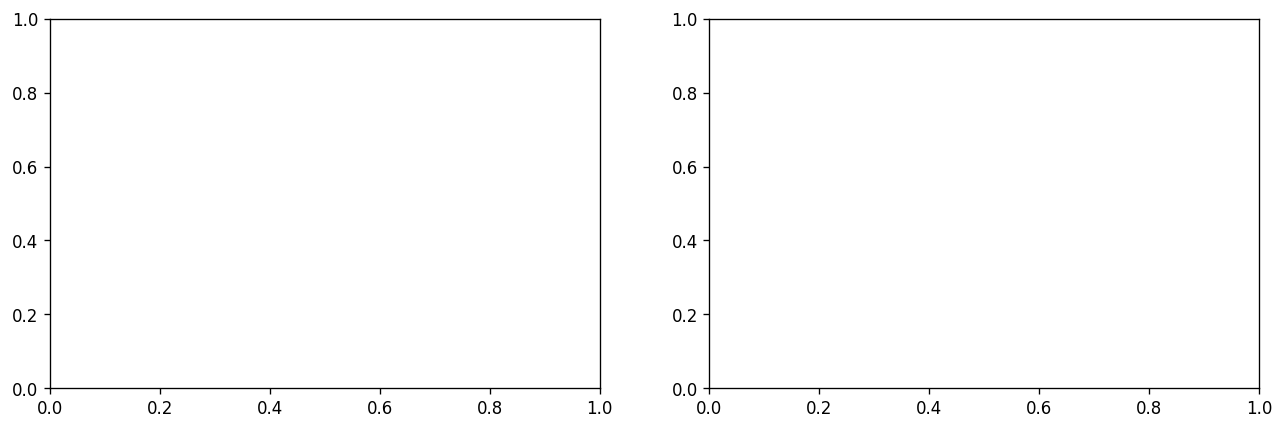

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
axes[0].hist(pheno['DTF'].dropna(), bins=35, color='#2a9d8f', edgecolor='white', linewidth=0.5)
axes[0].axvline(pheno['DTF'].mean(), color='#e76f51', lw=2, linestyle='--', label=f'Mean = {pheno["DTF"].mean():.1f} days')
axes[0].set_xlabel('Days to Flowering', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Phenotypic Distribution — Days to Flowering\n(ProFaba Diversity Panel)', fontsize=12)
axes[0].legend()

# Boxplot if multiple environments exist
env_cols = [c for c in pheno_raw.columns if 'flower' in c.lower() or 'dtf' in c.lower()]
if len(env_cols) > 1:
    env_data = pheno_raw[env_cols].apply(pd.to_numeric, errors='coerce')
    env_data.boxplot(ax=axes[1])
    axes[1].set_title('DTF Across Environments', fontsize=12)
    axes[1].set_ylabel('Days to Flowering')
    axes[1].tick_params(axis='x', rotation=30)
else:
    axes[1].boxplot(pheno['DTF'].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2a9d8f'))
    axes[1].set_title('DTF Distribution (Boxplot)', fontsize=12)
    axes[1].set_ylabel('Days to Flowering')
    axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('01_phenotype_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved: 01_phenotype_distribution.png')

## 🧬 Step 5 — Parse Genotypic Data (VCF → SNP Matrix)

The VCF file contains 539,643 SNP markers. We parse it into a numeric matrix:
- **0** = homozygous reference (AA)
- **1** = heterozygous (AB)
- **2** = homozygous alternate (BB)
- **NaN** = missing

Because the full VCF is large (~33 MB compressed), we first check which samples are in
both the VCF and phenotype file, then build the matrix only for shared samples.

In [ ]:
import gzip

# --- Step 5a: Read VCF header to get sample names ---
print('Reading VCF header for sample names...')
vcf_samples = []
with gzip.open(VCF_FILE, 'rt') as f:
    for line in f:
        if line.startswith('#CHROM'):
            parts = line.strip().split('\t')
            vcf_samples = parts[9:]   # samples start at column 9
            break

print(f'Samples in VCF  : {len(vcf_samples)}')
print(f'Sample IDs (first 10): {vcf_samples[:10]}')

In [ ]:
# --- Step 5b: Find samples present in BOTH VCF and phenotype ---
pheno_ids  = set(pheno.index.astype(str))
vcf_ids    = set(vcf_samples)
shared_ids = sorted(pheno_ids & vcf_ids)

print(f'Accessions in phenotype file : {len(pheno_ids)}')
print(f'Samples in VCF               : {len(vcf_ids)}')
print(f'Shared (have both data types): {len(shared_ids)}')

if len(shared_ids) == 0:
    print()
    print('⚠️  No exact ID matches found!')
    print('   This likely means IDs need minor formatting (e.g. prefix/suffix differences).')
    print('   Showing first 10 phenotype IDs vs first 10 VCF IDs for comparison:')
    print('   Phenotype:', sorted(pheno_ids)[:10])
    print('   VCF:      ', vcf_samples[:10])
    print()
    print('   Fix: adjust the ID_COL detection in Step 3 or strip/rename IDs here.')
else:
    print(f'\n✅ Proceeding with {len(shared_ids)} accessions that have both genotype AND phenotype.')

In [ ]:
# --- Step 5c: Parse VCF into numeric SNP matrix (shared samples only) ---
# We sample every N-th SNP to keep memory manageable in Colab
# For a proper analysis, increase SNP_SAMPLE_RATE toward 1.0

SNP_SAMPLE_RATE = 0.05   # use 5% of SNPs (~27,000) — fast and memory-safe
                          # For full analysis: SNP_SAMPLE_RATE = 1.0 (needs ~8 GB RAM)

def parse_gt(gt_str):
    """Convert VCF genotype string to allele dosage (0/1/2/NaN)."""
    if gt_str in ('.', './.', '.|.'):
        return np.nan
    sep = '|' if '|' in gt_str else '/'
    alleles = gt_str.split(sep)
    try:
        return sum(int(a) for a in alleles if a != '.')
    except:
        return np.nan

# Index of each shared sample in the VCF column order
sample_idx  = {s: i for i, s in enumerate(vcf_samples)}
keep_cols   = [sample_idx[s] for s in shared_ids]  # column positions

snp_records = []   # list of (snp_id, [dosage values])
snp_ids     = []
rng         = np.random.default_rng(42)

print(f'Parsing VCF (sampling {SNP_SAMPLE_RATE*100:.0f}% of SNPs)...')
n_snps_total = 0
with gzip.open(VCF_FILE, 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        if rng.random() > SNP_SAMPLE_RATE:
            continue
        parts = line.rstrip().split('\t')
        chrom, pos, snp_id = parts[0], parts[1], parts[2]
        if snp_id == '.':
            snp_id = f'{chrom}_{pos}'
        fmt_fields = parts[8].split(':')
        gt_idx = fmt_fields.index('GT') if 'GT' in fmt_fields else 0
        dosages = []
        for col in keep_cols:
            sample_data = parts[9 + col].split(':')[gt_idx]
            dosages.append(parse_gt(sample_data))
        snp_ids.append(snp_id)
        snp_records.append(dosages)
        n_snps_total += 1

print(f'Parsed {n_snps_total:,} SNPs × {len(shared_ids)} accessions.')

# Build DataFrame: rows = accessions, columns = SNPs
G_raw = pd.DataFrame(
    np.array(snp_records, dtype=np.float32).T,
    index=shared_ids,
    columns=snp_ids
)
print(f'Genotype matrix shape: {G_raw.shape}')

In [ ]:
# --- Step 5d: QC — remove high-missingness SNPs and impute remaining ---
MISS_THRESHOLD = 0.20   # drop SNPs missing in >20% of samples

miss_rate = G_raw.isna().mean(axis=0)
G_filt    = G_raw.loc[:, miss_rate <= MISS_THRESHOLD].copy()
print(f'SNPs after missingness filter (<{MISS_THRESHOLD*100:.0f}%): {G_filt.shape[1]:,}')

# Impute remaining missing values with column mean (mean allele dosage)
imputer = SimpleImputer(strategy='mean')
G_imp   = pd.DataFrame(
    imputer.fit_transform(G_filt),
    index=G_filt.index,
    columns=G_filt.columns
)

# Also remove monomorphic SNPs (no variation = useless for GWAS/prediction)
var_mask = G_imp.var(axis=0) > 0
G        = G_imp.loc[:, var_mask]
print(f'SNPs after removing monomorphic: {G.shape[1]:,}')

# Align phenotype to genotype order
y = pheno.loc[G.index, 'DTF']
print(f'\nFinal dataset: {G.shape[0]} accessions × {G.shape[1]} SNPs')
print(f'DTF range: {y.min():.1f} – {y.max():.1f} days')

## 🗺️ Step 6 — Population Structure (PCA)

Before running GWAS, we must account for **population structure**.
Accessions from the same geographic origin share ancestry — this can create
false GWAS associations unless we control for it.

PCA of the SNP matrix reveals the main axes of genetic variation.

In [ ]:
# --- PCA on standardised SNP matrix ---
scaler = StandardScaler()
G_scaled = scaler.fit_transform(G)

pca = PCA(n_components=10, random_state=42)
PCs = pca.fit_transform(G_scaled)
PC_df = pd.DataFrame(PCs, index=G.index,
                     columns=[f'PC{i+1}' for i in range(10)])

# --- Plot PC1 vs PC2 coloured by DTF ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    PC_df['PC1'], PC_df['PC2'],
    c=y, cmap='RdYlGn_r', alpha=0.8, s=40, edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Days to Flowering')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].set_title('Population Structure PCA\nColoured by Days to Flowering', fontsize=12)

# Scree plot
axes[1].bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='#264653')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Variance Explained (%)', fontsize=11)
axes[1].set_title('Scree Plot — Top 10 PCs', fontsize=12)
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig('02_population_structure_PCA.png', bbox_inches='tight')
plt.show()
print('Figure saved: 02_population_structure_PCA.png')

## 🔬 Step 7 — GWAS: Which SNPs are Associated with Days to Flowering?

We run a **mixed linear model GWAS** — for each SNP we fit:

> `DTF ~ SNP_dosage + PC1 + PC2 + PC3` (controlling for population structure)

This is the standard approach used in published faba bean GWAS papers.
We use Bonferroni correction for multiple testing.

In [ ]:
from scipy.stats import linregress

# --- Build design matrix: PC covariates for population structure correction ---
N_PC_COVARIATES = 3
covariates = PC_df.iloc[:, :N_PC_COVARIATES].values  # shape: (n_samples, n_PCs)

# Residualise y on PCs (remove population structure effect from phenotype)
from numpy.linalg import lstsq
cov_with_intercept = np.hstack([np.ones((len(y), 1)), covariates])
beta_cov, _, _, _ = lstsq(cov_with_intercept, y.values, rcond=None)
y_resid = y.values - cov_with_intercept @ beta_cov

print('Running per-SNP association tests...')
p_values  = np.zeros(G.shape[1])
slopes    = np.zeros(G.shape[1])
snp_names = G.columns.tolist()

for i, snp in enumerate(snp_names):
    x = G[snp].values
    slope, intercept, r, p, se = linregress(x, y_resid)
    p_values[i] = p
    slopes[i]   = slope

gwas_df = pd.DataFrame({
    'SNP'    : snp_names,
    'slope'  : slopes,
    'pvalue' : p_values,
    'neglog10p': -np.log10(p_values + 1e-300)
})

# Parse chromosome and position from SNP IDs (format: CHR_POS or similar)
def parse_chrom_pos(snp_id):
    parts = str(snp_id).replace('chr', '').split('_')
    try:
        chrom = int(parts[0])
        pos   = int(parts[1])
    except:
        chrom, pos = 0, 0
    return chrom, pos

gwas_df[['chrom', 'pos']] = gwas_df['SNP'].apply(
    lambda x: pd.Series(parse_chrom_pos(x))
)
gwas_df = gwas_df.sort_values(['chrom', 'pos'])

# Bonferroni threshold
bonferroni = 0.05 / len(gwas_df)
n_sig = (gwas_df['pvalue'] < bonferroni).sum()
print(f'\n✅ GWAS complete. {n_sig} SNPs significant after Bonferroni correction (α={bonferroni:.2e})')
print(gwas_df.nsmallest(10, 'pvalue')[['SNP', 'chrom', 'pos', 'slope', 'pvalue']].to_string(index=False))

In [ ]:
# --- Manhattan Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

CHROM_COLORS = ['#264653', '#2a9d8f']
chroms = sorted(gwas_df['chrom'].unique())
chrom_offsets = {}
offset = 0
xtick_pos, xtick_labels = [], []

for i, chrom in enumerate(chroms):
    chrom_data = gwas_df[gwas_df['chrom'] == chrom]
    xs = chrom_data['pos'] + offset
    color = CHROM_COLORS[i % 2]
    ax.scatter(xs, chrom_data['neglog10p'], c=color, s=6, alpha=0.7, linewidths=0)
    xtick_pos.append(xs.mean())
    xtick_labels.append(f'Chr{chrom}' if chrom != 0 else 'Unknown')
    chrom_offsets[chrom] = offset
    offset += chrom_data['pos'].max() + 5_000_000

bonferroni_line = -np.log10(bonferroni)
suggestive_line = -np.log10(1e-5)
ax.axhline(bonferroni_line, color='red',    lw=1.2, linestyle='--', label=f'Bonferroni (p={bonferroni:.1e})')
ax.axhline(suggestive_line, color='orange', lw=1.0, linestyle=':', label='Suggestive (p=1e-5)')

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_xlabel('Chromosome', fontsize=12)
ax.set_ylabel('−log₁₀(p-value)', fontsize=12)
ax.set_title('Manhattan Plot — Days to Flowering GWAS\n(ProFaba Diversity Panel)', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('03_manhattan_plot.png', bbox_inches='tight')
plt.show()
print('Figure saved: 03_manhattan_plot.png')

In [ ]:
# --- QQ Plot: check for genomic inflation ---
observed  = np.sort(-np.log10(gwas_df['pvalue'].values + 1e-300))[::-1]
expected  = -np.log10(np.linspace(1, 1/len(observed), len(observed)))
lambda_gc = np.median(stats.chi2.ppf(1 - gwas_df['pvalue'].values, df=1)) / stats.chi2.ppf(0.5, df=1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=5, alpha=0.5, c='#264653')
ax.plot([0, expected.max()], [0, expected.max()], 'r--', lw=1.5, label='y = x (expected)')
ax.set_xlabel('Expected −log₁₀(p)', fontsize=11)
ax.set_ylabel('Observed −log₁₀(p)', fontsize=11)
ax.set_title(f'QQ Plot — Genomic Inflation λ = {lambda_gc:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('04_qq_plot.png', bbox_inches='tight')
plt.show()
print(f'\nGenomic inflation factor λ = {lambda_gc:.3f}')
print('λ close to 1.0 = good (no systematic inflation). >1.1 = may need more PCs.')

## 🤖 Step 8 — Genomic Prediction (ML Models)

Now we switch from association testing to **prediction**: can we predict DTF
for new accessions from their SNP profile?

We compare three models:
1. **Ridge Regression (GBLUP-equivalent)** — the standard genomic selection baseline
2. **Random Forest** — non-linear, powerful, interpretable via SHAP
3. **Gradient Boosting** — often best predictive performance

We use **5-fold cross-validation** (the gold standard for genomic prediction).

In [ ]:
# --- Use top GWAS SNPs for ML (dimensionality reduction + biological focus) ---
# In genomic prediction you can use all SNPs; here we select top 2000 by p-value
# for Colab memory efficiency. In a full analysis, use all SNPs.

N_TOP_SNPS = min(2000, G.shape[1])
top_snps   = gwas_df.nsmallest(N_TOP_SNPS, 'pvalue')['SNP'].values
G_top      = G[top_snps].values
y_arr      = y.values

print(f'Using top {N_TOP_SNPS} SNPs by GWAS p-value for prediction models.')
print(f'Feature matrix shape: {G_top.shape}')

In [ ]:
# --- 5-fold cross-validation for all three models ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Ridge (GBLUP-like)'    : RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000]),
    'Random Forest'         : RandomForestRegressor(n_estimators=200, max_features=0.3,
                                                     min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                         learning_rate=0.05, random_state=42),
}

results = {}
oof_preds = {}   # out-of-fold predictions for plotting

for name, model in models.items():
    print(f'Training: {name} ...')
    oof = np.zeros(len(y_arr))
    for train_idx, val_idx in kf.split(G_top):
        Xtr, Xval = G_top[train_idx], G_top[val_idx]
        ytr, yval = y_arr[train_idx], y_arr[val_idx]
        model.fit(Xtr, ytr)
        oof[val_idx] = model.predict(Xval)
    r2  = r2_score(y_arr, oof)
    mse = mean_squared_error(y_arr, oof)
    cor = np.corrcoef(y_arr, oof)[0, 1]
    results[name] = {'R²': r2, 'MSE': mse, 'Pearson_r': cor}
    oof_preds[name] = oof
    print(f'  R² = {r2:.3f}  |  Pearson r = {cor:.3f}  |  RMSE = {np.sqrt(mse):.2f} days')

print('\n=== Summary ===')
print(pd.DataFrame(results).T.round(3).to_string())

In [ ]:
# --- Predicted vs Actual plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, oof) in zip(axes, oof_preds.items()):
    r2 = r2_score(y_arr, oof)
    cor = np.corrcoef(y_arr, oof)[0, 1]
    ax.scatter(y_arr, oof, alpha=0.6, s=25, c='#2a9d8f', edgecolors='none')
    mn, mx = min(y_arr.min(), oof.min()), max(y_arr.max(), oof.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel('Actual DTF (days)', fontsize=10)
    ax.set_ylabel('Predicted DTF (days)', fontsize=10)
    ax.set_title(f'{name}\nR² = {r2:.3f}  |  r = {cor:.3f}', fontsize=10)

plt.suptitle('Genomic Prediction of Days to Flowering — 5-fold CV', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('05_prediction_accuracy.png', bbox_inches='tight')
plt.show()
print('Figure saved: 05_prediction_accuracy.png')

## 🔍 Step 9 — Explainability: Which SNPs Drive the Prediction?

We use **SHAP (SHapley Additive exPlanations)** on the Random Forest model.
SHAP tells us:
- Which SNPs pushed predictions up or down
- The direction of effect (early vs late flowering allele)
- Whether the top SHAP SNPs overlap with GWAS hits

This is the "interpretable AI" component central to Prof. Golicz's research vision.

In [ ]:
# --- Re-fit Random Forest on full data for SHAP ---
rf_full = RandomForestRegressor(n_estimators=300, max_features=0.3,
                                 min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_full.fit(G_top, y_arr)

print('Computing SHAP values (this may take ~1 min)...')
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(G_top)
print('✅ SHAP values computed.')

In [ ]:
# --- SHAP Summary Bar Plot: Top 20 most important SNPs ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=top_snps).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top20_shap = shap_importance.head(20)
bars = ax.barh(range(20), top20_shap.values[::-1], color='#2a9d8f', edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels(top20_shap.index[::-1], fontsize=8)
ax.set_xlabel('Mean |SHAP value| (impact on DTF prediction)', fontsize=11)
ax.set_title('Top 20 SNPs by SHAP Importance\n(Random Forest — Days to Flowering)', fontsize=12)
plt.tight_layout()
plt.savefig('06_shap_importance.png', bbox_inches='tight')
plt.show()
print('Figure saved: 06_shap_importance.png')

In [ ]:
# --- SHAP Beeswarm: direction of effect ---
# Blue = low allele dosage (reference), Red = high allele dosage (alternate)
# Right = increased DTF (later flowering), Left = decreased DTF (earlier flowering)

plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    features=G_top,
    feature_names=top_snps,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — SNP Effects on Days to Flowering', fontsize=12)
plt.tight_layout()
plt.savefig('07_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Figure saved: 07_shap_beeswarm.png')

## ⚖️ Step 10 — Benchmark: GWAS vs ML — Do They Agree?

A core duty of this PhD is benchmarking new AI methods against established GWAS.
Here we compare:
- **GWAS top hits** (by smallest p-value)
- **ML top hits** (by highest mean |SHAP|)

Overlap = both methods point to the same genomic region → high confidence discovery.

In [ ]:
N_TOP = 50  # compare top N SNPs from each method

gwas_top = set(gwas_df.nsmallest(N_TOP, 'pvalue')['SNP'].values)
shap_top = set(shap_importance.head(N_TOP).index)
overlap  = gwas_top & shap_top

print(f'Top {N_TOP} GWAS SNPs  : {len(gwas_top)}')
print(f'Top {N_TOP} SHAP SNPs  : {len(shap_top)}')
print(f'Overlap (both methods): {len(overlap)}')
print(f'Agreement rate: {len(overlap)/N_TOP*100:.1f}%')
if overlap:
    print('\nShared SNPs (high confidence candidates):')
    for snp in sorted(overlap):
        gwas_row = gwas_df[gwas_df['SNP'] == snp].iloc[0]
        shap_val = shap_importance[snp]
        print(f'  {snp:30s}  GWAS p={gwas_row["pvalue"]:.2e}  |  SHAP={shap_val:.4f}')

In [ ]:
# --- Venn-style bar chart: GWAS rank vs SHAP rank for top SNPs ---
all_top = gwas_top | shap_top
gwas_ranks = {snp: i+1 for i, snp in enumerate(gwas_df.nsmallest(N_TOP*2, 'pvalue')['SNP'])}
shap_ranks = {snp: i+1 for i, snp in enumerate(shap_importance.head(N_TOP*2).index)}

rank_data = []
for snp in all_top:
    rank_data.append({
        'SNP'       : snp,
        'GWAS_rank' : gwas_ranks.get(snp, N_TOP*2 + 1),
        'SHAP_rank' : shap_ranks.get(snp, N_TOP*2 + 1),
        'in_both'   : snp in overlap
    })

rank_df = pd.DataFrame(rank_data)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#e76f51' if b else '#adb5bd' for b in rank_df['in_both']]
ax.scatter(rank_df['GWAS_rank'], rank_df['SHAP_rank'],
           c=colors, alpha=0.8, s=50, edgecolors='none')
ax.set_xlabel('GWAS Rank (by p-value)', fontsize=11)
ax.set_ylabel('SHAP Rank (by importance)', fontsize=11)
ax.set_title('GWAS vs ML (SHAP) SNP Rankings\nRed = found by both methods', fontsize=12)
red_patch = mpatches.Patch(color='#e76f51', label=f'In both (n={len(overlap)})')
grey_patch = mpatches.Patch(color='#adb5bd', label='In one method only')
ax.legend(handles=[red_patch, grey_patch])
plt.tight_layout()
plt.savefig('08_gwas_vs_ml_benchmark.png', bbox_inches='tight')
plt.show()
print('Figure saved: 08_gwas_vs_ml_benchmark.png')

## 💾 Step 11 — Save All Results

In [ ]:
# GWAS results table
gwas_df.sort_values('pvalue').to_csv('gwas_results_DTF.csv', index=False)
print('Saved: gwas_results_DTF.csv')

# SHAP importance table
shap_importance.reset_index().rename(columns={'index': 'SNP', 0: 'mean_abs_SHAP'})\
    .to_csv('shap_importance_DTF.csv', index=False)
print('Saved: shap_importance_DTF.csv')

# Model performance summary
pd.DataFrame(results).T.round(4).to_csv('model_performance_summary.csv')
print('Saved: model_performance_summary.csv')

# Phenotype + PC + OOF predictions (for further analysis)
output_df = pd.DataFrame({
    'accession'    : G.index,
    'DTF_observed' : y_arr,
    'PC1'          : PC_df['PC1'].values,
    'PC2'          : PC_df['PC2'].values,
})
for name, oof in oof_preds.items():
    output_df[f'DTF_pred_{name.split()[0]}'] = oof
output_df.to_csv('accession_predictions_DTF.csv', index=False)
print('Saved: accession_predictions_DTF.csv')

print('\n✅ All results saved!')

## 📋 Step 12 — Summary & PhD Roadmap

---

### What this project demonstrated

| Step | Method | Output |
|------|---------|--------|
| Phenotype QC | Distribution, outlier check | `01_phenotype_distribution.png` |
| Population structure | PCA on 539k SNPs | `02_population_structure_PCA.png` |
| GWAS | Linear regression + PC correction + Bonferroni | `03_manhattan_plot.png`, `gwas_results_DTF.csv` |
| Genomic prediction | Ridge, Random Forest, Gradient Boosting (5-fold CV) | `05_prediction_accuracy.png` |
| Interpretability | SHAP values on Random Forest | `06_shap_importance.png`, `07_shap_beeswarm.png` |
| Benchmarking | GWAS rank vs ML rank comparison | `08_gwas_vs_ml_benchmark.png` |

---

### 🚀 Next steps toward the full PhD project

1. **Run with full SNP set** (`SNP_SAMPLE_RATE = 1.0`) for publication-quality GWAS
2. **Use proper mixed model GWAS** (e.g. `rMVP` in R or `GEMMA`) with kinship matrix
3. **Add transcriptomics layer** — integrate RNA-seq expression as additional features
4. **Single-cell data** — link cell-type-specific gene expression to DTF via eQTL mapping
5. **Multi-environment analysis** — repeat per location and study G×E interactions
6. **Graph neural network** — model SNP-gene-trait relationships as a network
7. **Pangenome integration** — use structural variants (Golicz et al. 2025 approach) as features

---

**Dataset citation:**  
Bornhofen E. et al. (2024). *Genotypic and phenotypic data for the ProFaba diverse panel of faba bean accessions.* Zenodo. https://doi.org/10.5281/zenodo.13908861

**Reference genome:**  
Jayakodi M., Golicz A.A. et al. (2023). *The giant diploid faba genome unlocks variation in a global protein crop.* Nature 615, 652–659. https://doi.org/10.1038/s41586-023-05791-5